In [1]:
import pandas as pd

# Load data
df = pd.read_csv("D:\\New folder\\Cars_data (1).csv")

# Clean numeric columns with commas and strings at the end (e.g., "10,000 km", "15.5 L", "100 bhp")
numeric_cols = ["price", "km_driven", "mileage_new", "max_engine_capacity_new"]
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)  # Ensure all values are strings
        .str.replace(",", "", regex=False)  # Remove commas
        .str.extract(r"([0-9.]+)")  # Extract numeric part using regex
        .squeeze()  # Convert DataFrame to Series if needed
        .astype(float)  # Convert to float
    )

# Verify the cleaned columns
print(df[numeric_cols].head())
df["car_age"] = 2025 - df["model_year_new"]




      price  km_driven  mileage_new  max_engine_capacity_new
0  950000.0   150000.0        12.99                   2494.0
1  500000.0    53755.0        15.10                   2179.0
2  738000.0    53838.0        18.53                   1199.0
3  850000.0    28112.0        15.80                   1591.0
4  899999.0    63125.0        24.52                   1248.0


In [2]:
df = df[df["car_age"] <= 30]

In [3]:
print(df['utype'].unique())
owner_type_order = {
    "Individual": 1,
    "Dealer": 2
}
df["utype_encoded"] = df["utype"].map(owner_type_order)
print(df[["utype_encoded", "utype"]].head())

['Individual' 'Dealer']
   utype_encoded       utype
0              1  Individual
1              2      Dealer
2              2      Dealer
3              2      Dealer
4              2      Dealer


In [4]:
print(df['owner_type_new'].unique())
# Ordinal encoding for 'owner_type_new'
owner_type_order = {
    "fifth": 1,
    "fourth": 2,
    "third": 3,
    "second": 4,
    "first": 5,
    "unregistered car": 6,
}
df["owner_type_encoded"] = df["owner_type_new"].map(owner_type_order)
print(df[["owner_type_new", "owner_type_encoded"]].head())

['second' 'first' 'third' 'fourth' 'fifth' 'unregistered car']
  owner_type_new  owner_type_encoded
0         second                   4
1          first                   5
2          first                   5
3          first                   5
4          first                   5


In [5]:
# Example: "100.6bhp@3600rpm" → 100.6
df["max_power"] = df["Max Power"].str.extract(r"(\d+\.\d+|\d+)").astype(float)
df["max_torque"] = df["Max Torque"].str.extract(r"(\d+\.\d+|\d+)").astype(float)


In [6]:
# Drop rows with missing price
df.dropna(subset=["price"], inplace=True)

# Fill missing values
df["mileage_new"].fillna(df["mileage_new"].median())

0        12.99
1        15.10
2        18.53
3        15.80
4        24.52
         ...  
34028    17.42
34029    27.39
34030    18.60
34031    18.60
34032    21.21
Name: mileage_new, Length: 34027, dtype: float64

In [7]:
df["max_power"].fillna(df["max_power"].median())
df["max_torque"].fillna(df["max_torque"].median())

0        200.0
1        330.0
2        113.0
3        151.0
4        200.0
         ...  
34028    320.0
34029    190.0
34030    114.7
34031    114.7
34032    113.0
Name: max_torque, Length: 34027, dtype: float64

In [8]:
# Remove rows where 'max_engine_capacity_new' is equal to 0
df = df[df['max_engine_capacity_new'] != 0]

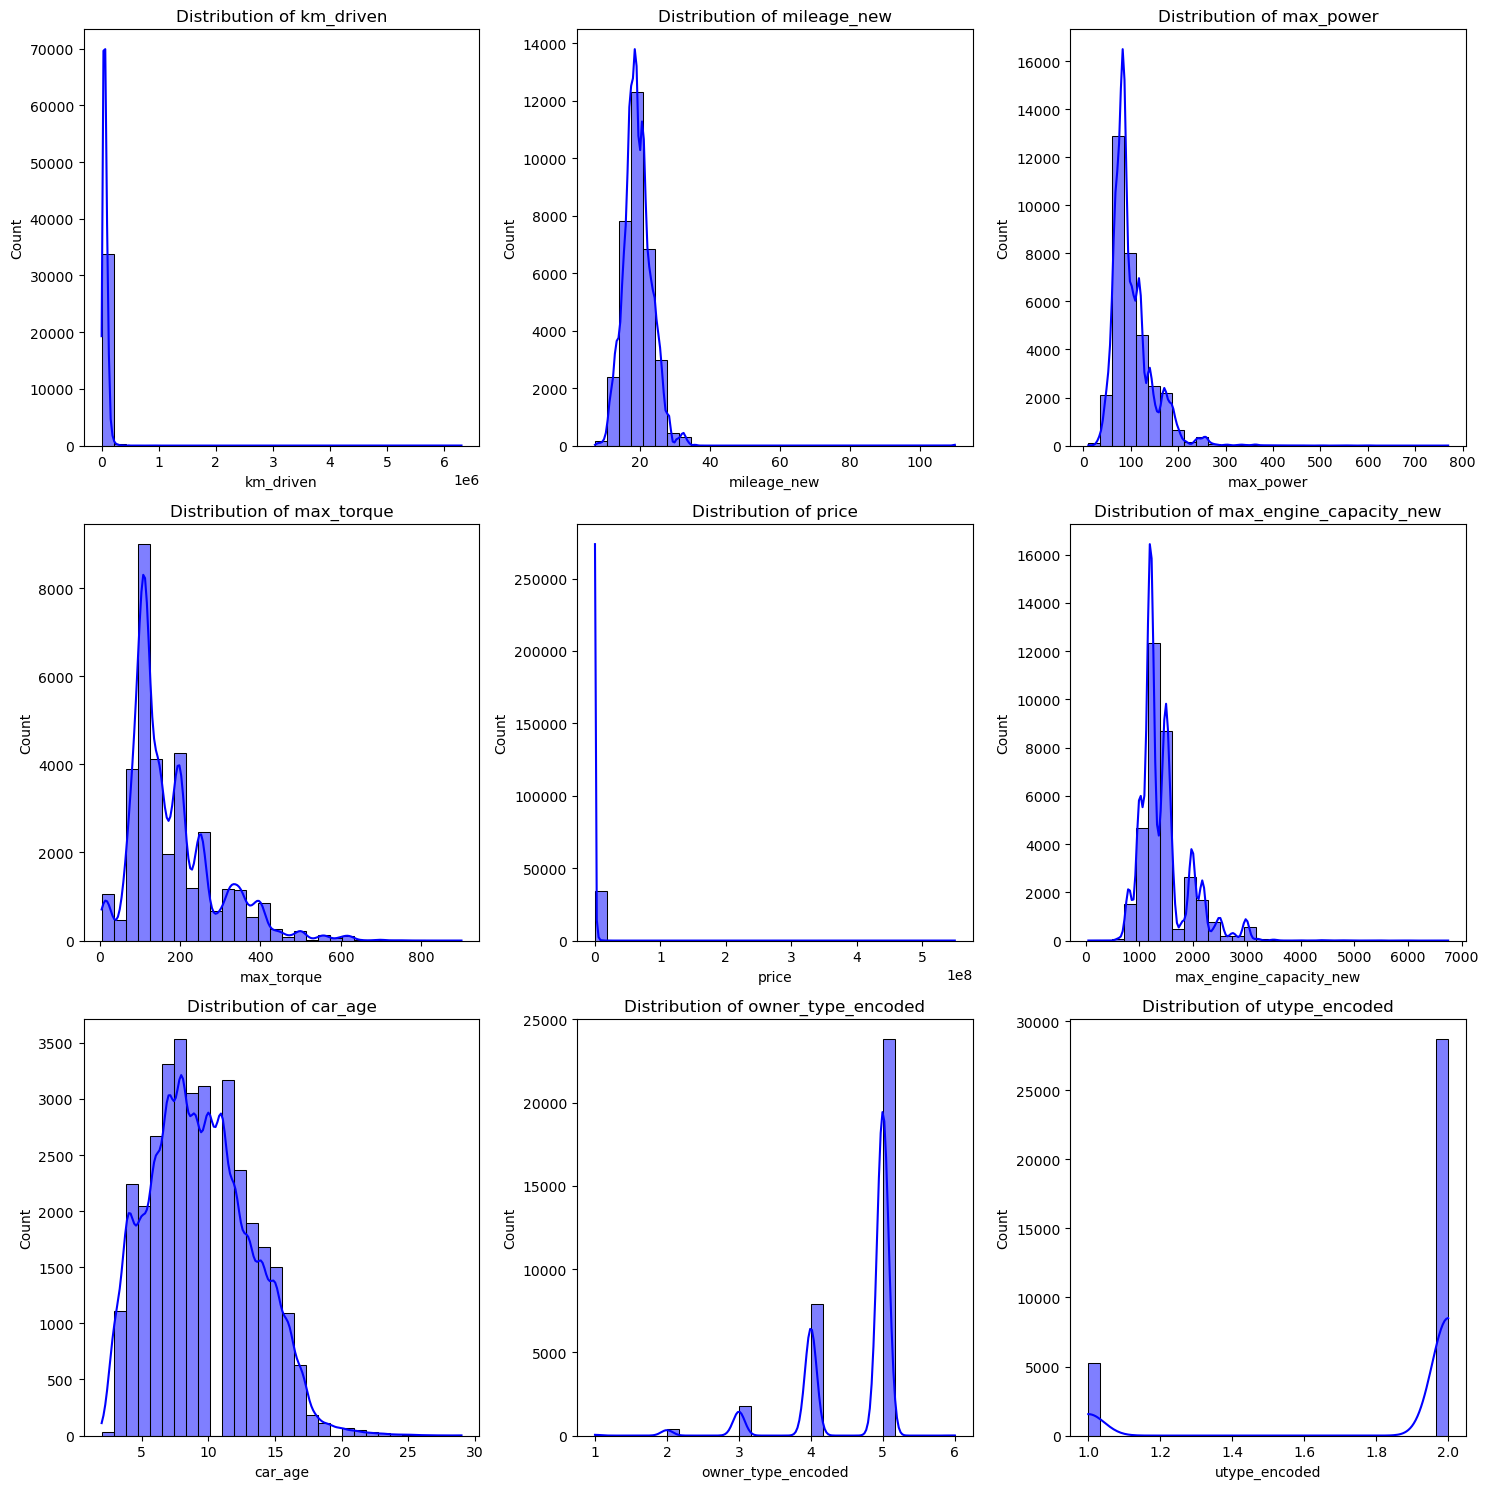

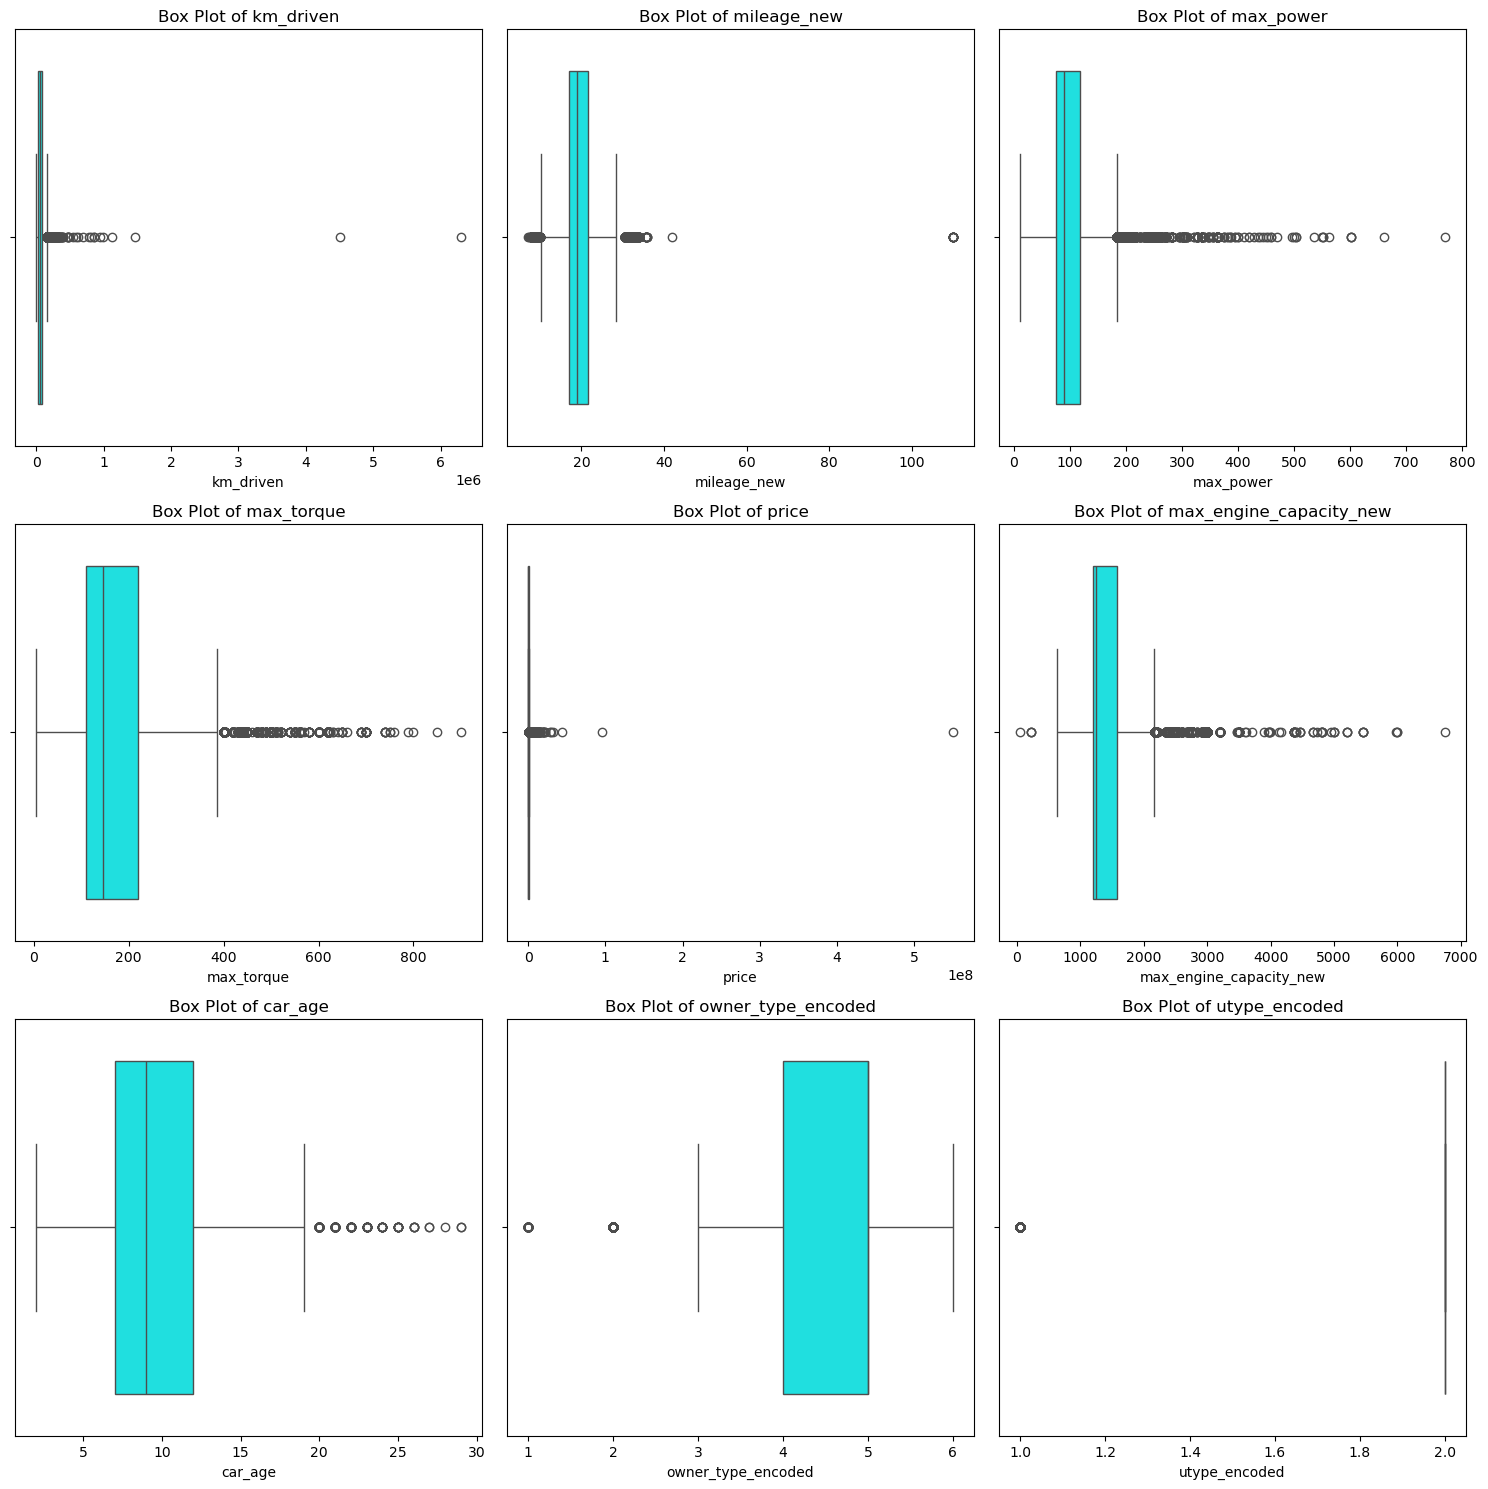

In [9]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (including int, float, bool)
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "mileage_new",
    "max_power", "max_torque", "price",
    "max_engine_capacity_new", "car_age", "owner_type_encoded", "utype_encoded"
]
#"utype_individual"  , "utype_dealer",
# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [10]:
import numpy as np

# Define columns to check for outliers
log_cols = ["owner_type_encoded",'max_power', 'max_torque', 'max_engine_capacity_new', 
            'price', "km_driven","car_age", "mileage_new"]

# For each column, remove rows where the value is outside 1.5*IQR from Q1 or Q3
for col in log_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

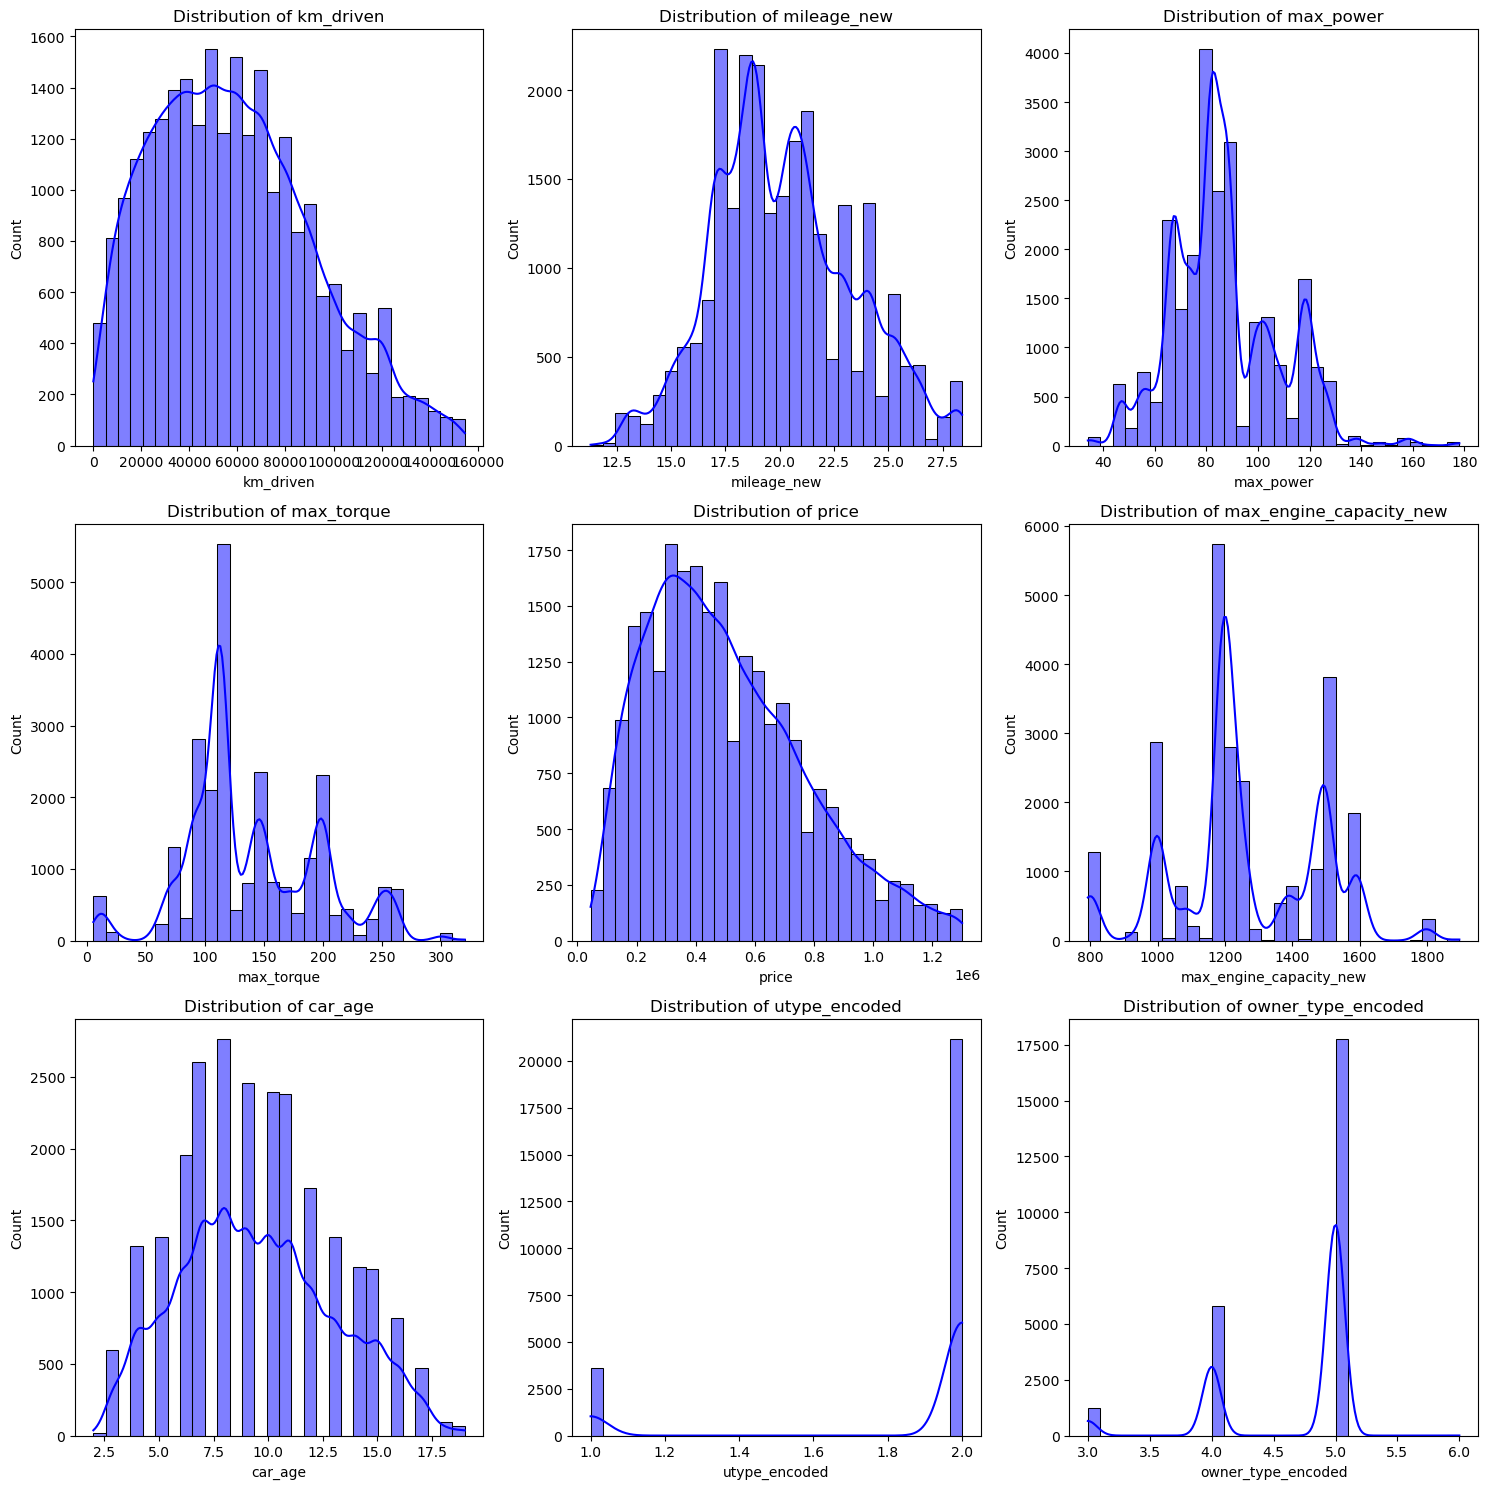

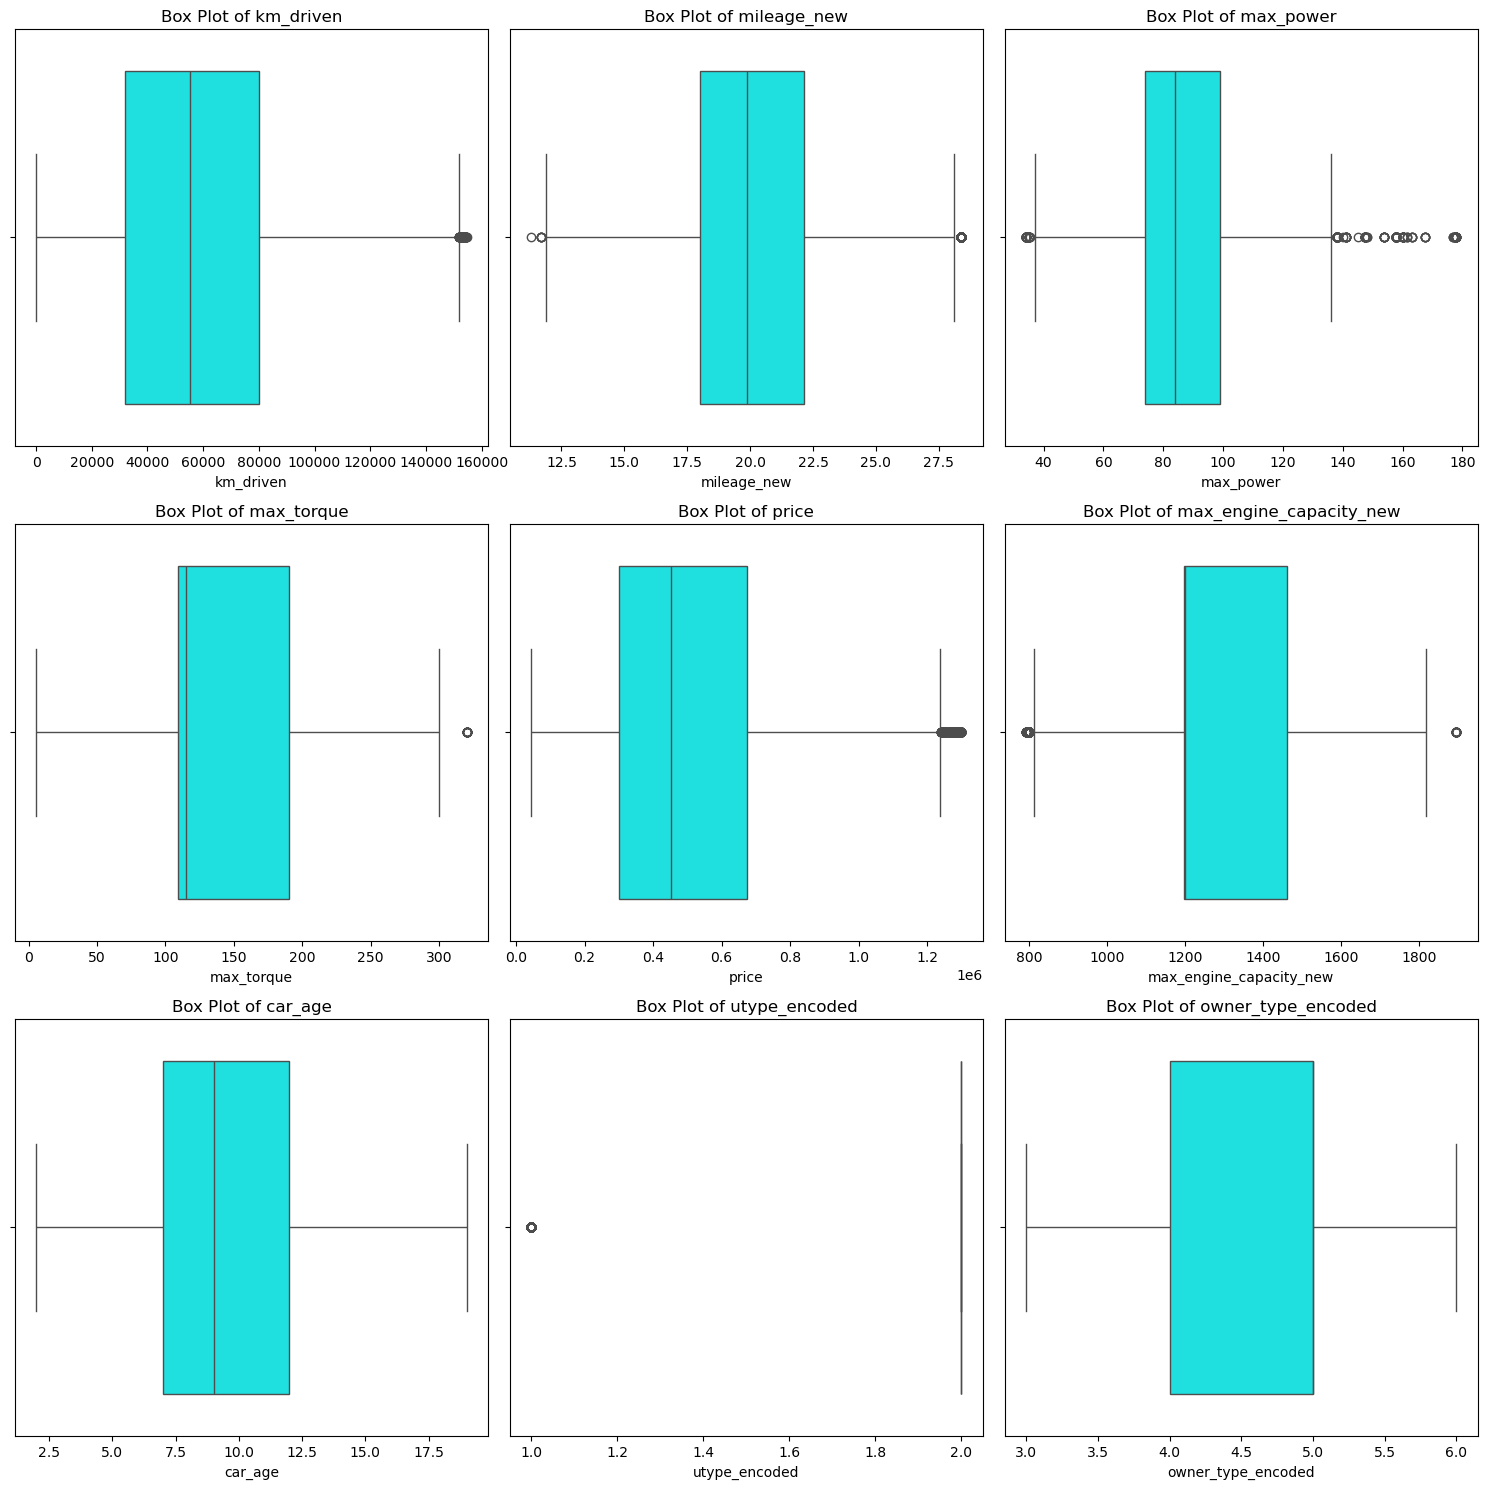

In [11]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (including int, float, bool)
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "mileage_new",
    "max_power", "max_torque", "price",
    "max_engine_capacity_new", "car_age", "utype_encoded",
    "owner_type_encoded"
]
#"utype_individual"  , "utype_dealer",
# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

In [12]:
import numpy as np

df["log_max_power"] = np.log(df["max_power"])
df["log_max_torque"] = np.log(df["max_torque"])
df["log_max_engine_capacity_new"] = np.log(df["max_engine_capacity_new"])
df["log_km_driven"] = np.log(df["km_driven"])
df["log_car_age"] = np.log(df["car_age"])
df["log_mileage_new"] = np.log(df["mileage_new"])


In [13]:
import numpy as np

features = [
 "log_km_driven", "mileage_new", 
    "log_max_power", "log_max_torque",
 "log_max_engine_capacity_new", "log_car_age",
   "owner_type_encoded", "utype_encoded"
]
#,"owner_type_encoded", "utype_encoded"
df = df.dropna(subset=["price"])
df = df.dropna(subset=features)
X = df[features]
y = df["price"]
#y = np.log(df["price"])  # Natural logarithm (base e)

In [14]:
# Identify negative values in 'max_engine_capacity_new'
neg_values = df[df['max_engine_capacity_new'] < 0]
print("Rows with negative 'max_engine_capacity_new':")
print(neg_values[['max_engine_capacity_new']])
print(f"Total negative values: {len(neg_values)}")

Rows with negative 'max_engine_capacity_new':
Empty DataFrame
Columns: [max_engine_capacity_new]
Index: []
Total negative values: 0


In [15]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


X_train, X_val = train_test_split(X,test_size=0.2,random_state=44,shuffle=True)
y_train, y_val = train_test_split(y,test_size=0.2,random_state=44,shuffle=True)



scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


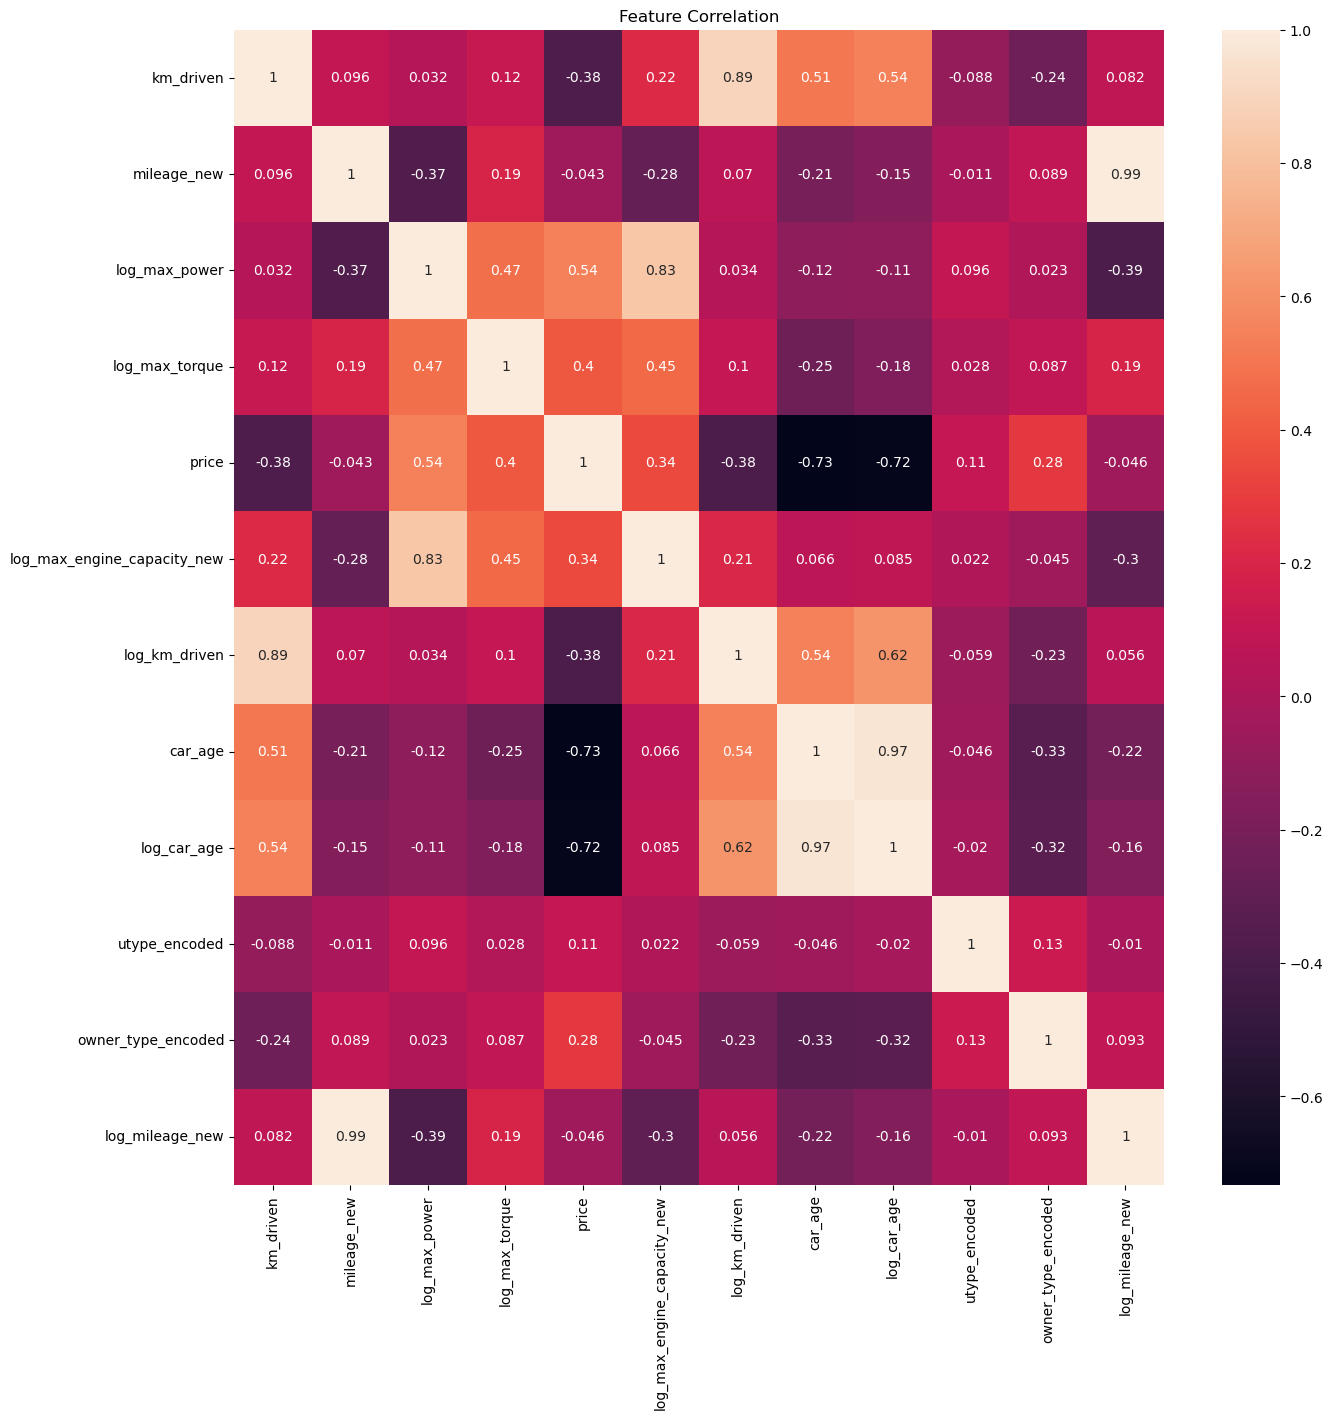

In [16]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

plt.figure(figsize=(15, 15))

sns.heatmap(df[[
"km_driven", "mileage_new", 
    "log_max_power", "log_max_torque", "price",
 "log_max_engine_capacity_new", "log_km_driven", "car_age", "log_car_age", "utype_encoded", "owner_type_encoded", "log_mileage_new"
]].corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

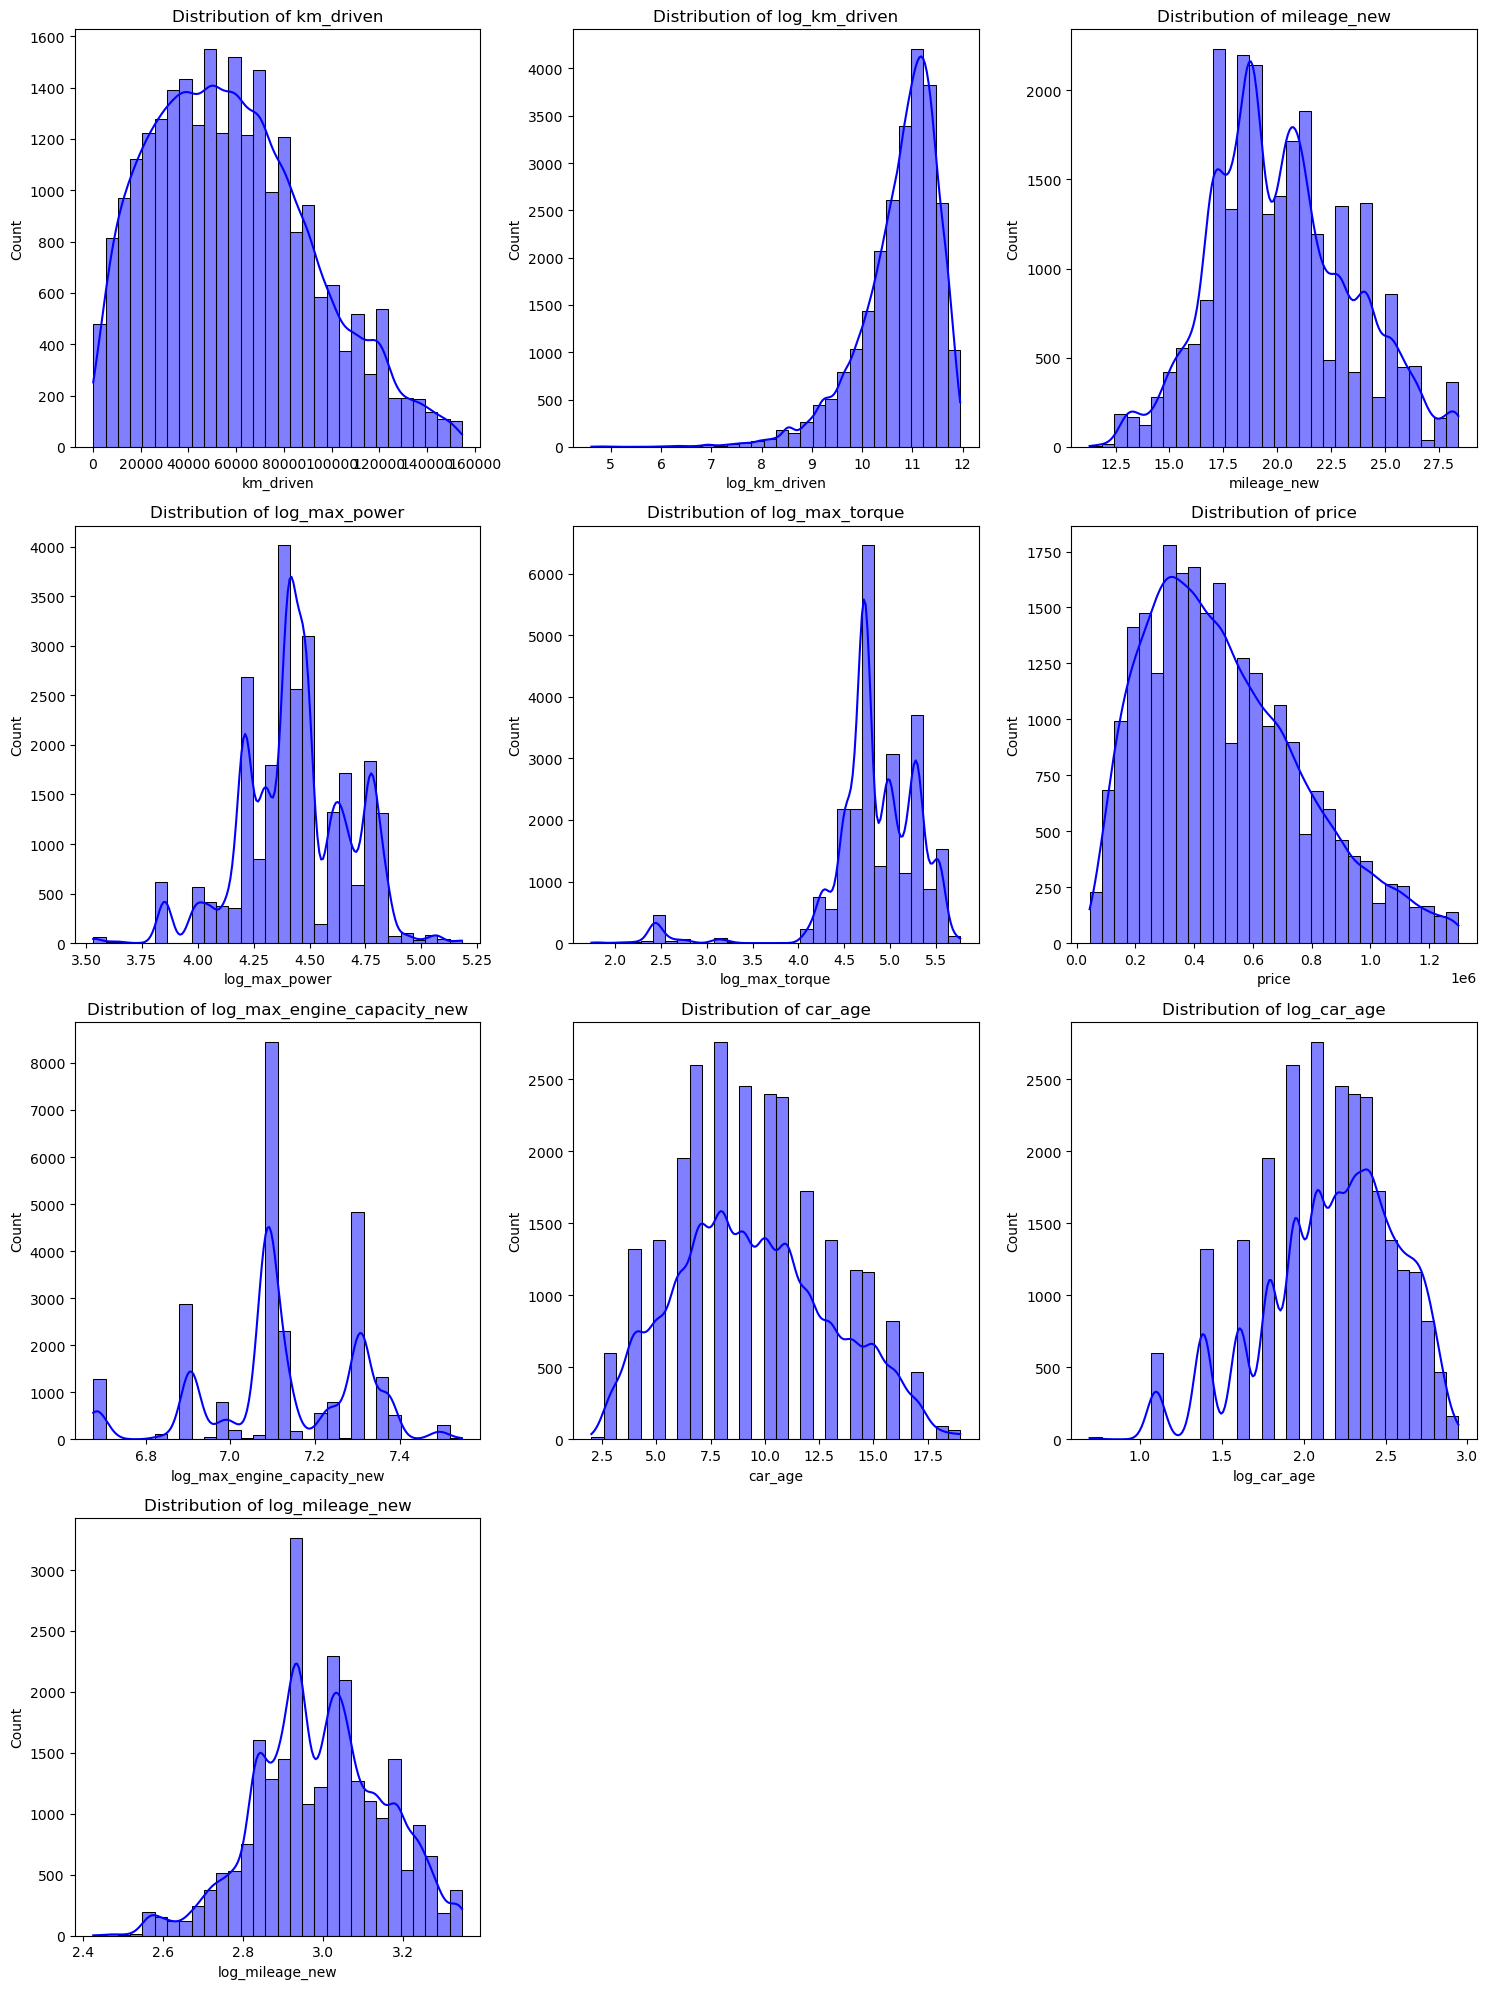

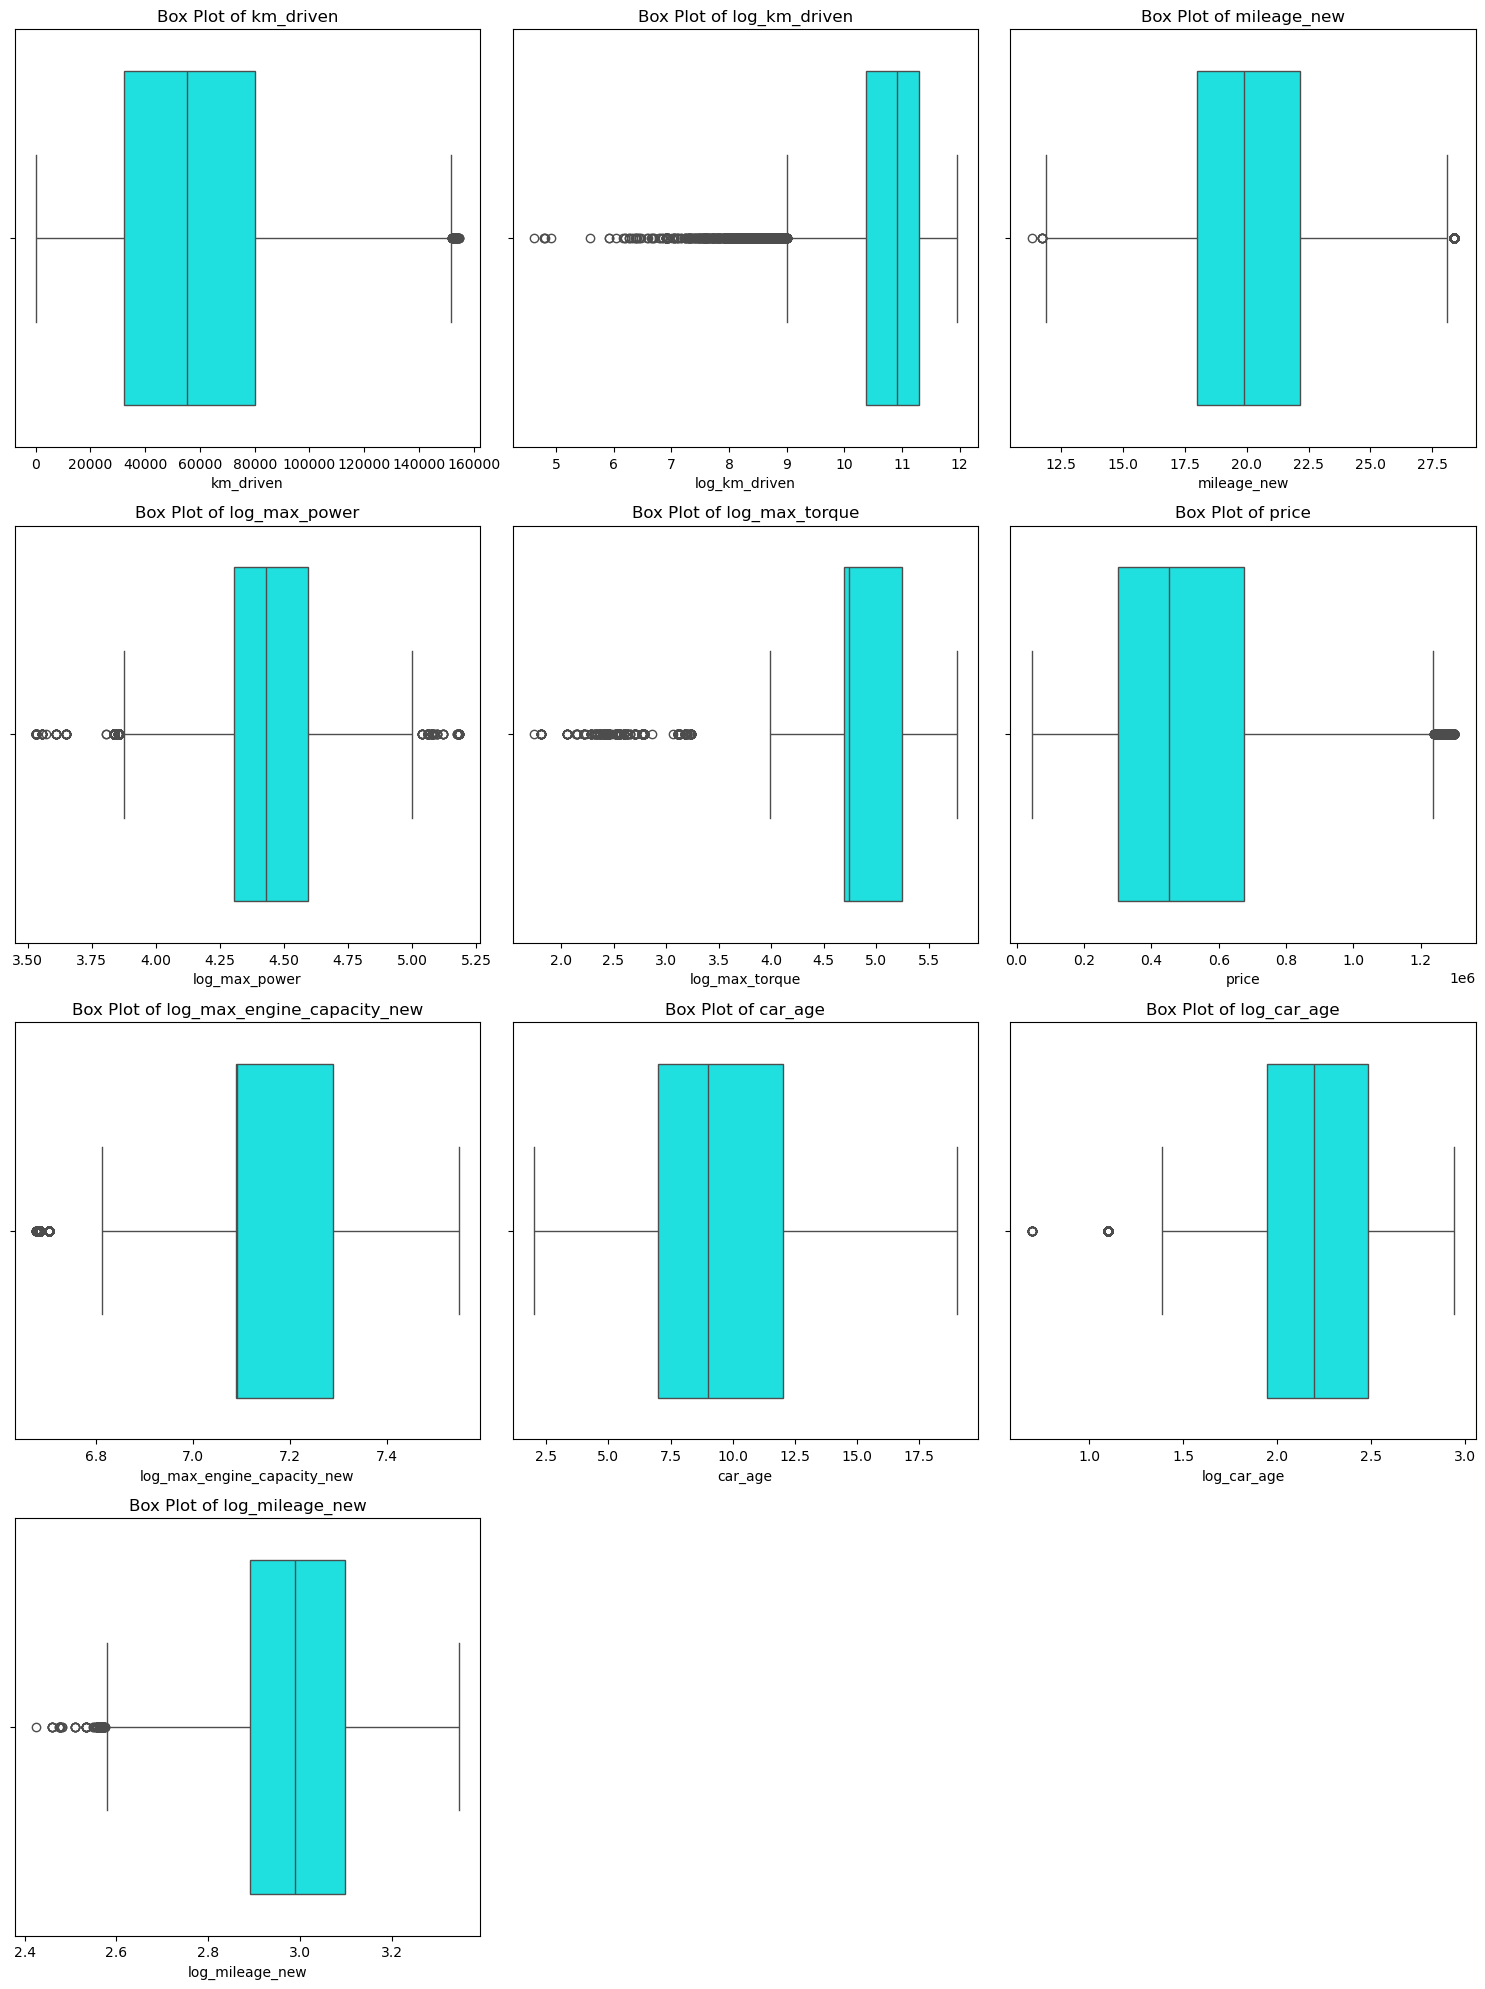

In [17]:
# Plot histograms and correlation heatmap for all numerical features
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select all numerical columns (including int, float, bool)
# Change the numerical_columns assignment to use the specified columns from df
numerical_columns = [
    "km_driven", "log_km_driven","mileage_new",
    "log_max_power", "log_max_torque", "price",
    "log_max_engine_capacity_new", "car_age", "log_car_age", "log_mileage_new"
]
#"utype_individual"  , "utype_dealer",
# --- HISTOGRAMS ---
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,681 (780.00 KB)

 Trainable params: 199,681 (780.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
620/620 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 232711290880.0000 - mae: 400583.0938 - val_loss: 63246557184.0000 - val_mae: 199422.7188
Epoch 2/300
620/620 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 59691442176.0000 - mae: 195877.6250 - val_loss: 46049112064.0000 - val_mae: 169365.1562
Epoch 3/300
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 41479974912.0000 - mae: 160096.8594 - val_loss: 24253364224.0000 - val_mae: 121079.5625
Epoch 4/300
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 23505752064.0000 - mae: 119290.3359 - val_loss: 19026587648.0000 - val_mae: 107301.9531
Epoch 5/300
620/620 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 20014127104.0000 - mae: 109874.2500 - val_loss: 17756735488.0000 - val_mae: 103027.4688
Epoch 6/300
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 18834870272.0000 - mae: 106171.2812 - val_loss: 17163576320.0000 - val_mae: 101067.2656
Epoch 7/300
620/620 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 18684051456.0000 - mae: 105288.1719 - val_lo

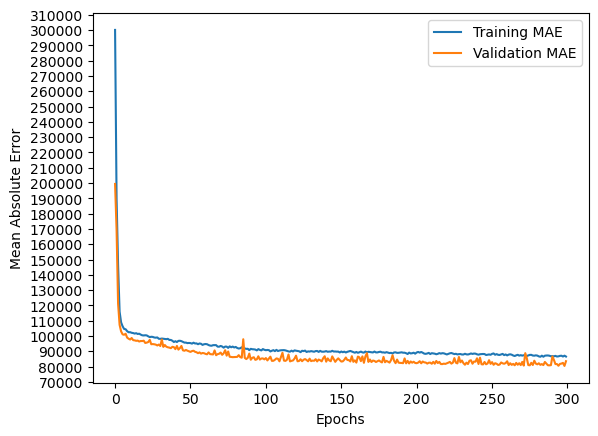

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model11 = Sequential([
    Dense(256, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(512, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(1)
])
model11.summary()
model11.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model11.fit(X_train, y_train, epochs=300,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()

In [20]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predict on validation or test set
y_pred_log = model11.predict(X_train).flatten()  # predictions in log scale
y_true_log = y_train  # true values in log scale

# Convert back to original scale
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_true_log)

# Calculate MAE in original price units
#mae_real = mean_absolute_error(y_true, y_pred)
#print("MAE in original price units:", mae_real)

620/620 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


C:\Users\narut\AppData\Local\Temp\ipykernel_18240\1146199981.py:9: RuntimeWarning: overflow encountered in exp
  y_pred = np.exp(y_pred_log)
c:\Users\narut\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 271091433472.0000 - mae: 443737.1250 - val_loss: 67458306048.0000 - val_mae: 206980.8594
Epoch 2/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 76635938816.0000 - mae: 220667.9844 - val_loss: 60090896384.0000 - val_mae: 194516.3125
Epoch 3/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 69391622144.0000 - mae: 208398.4375 - val_loss: 50163478528.0000 - val_mae: 176382.0312
Epoch 4/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 56031854592.0000 - mae: 185479.0312 - val_loss: 35667722240.0000 - val_mae: 145340.3906
Epoch 5/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 41418153984.0000 - mae: 157044.4375 - val_loss: 23006085120.0000 - val_mae: 118430.8984
Epoch 6/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31641556992.0000 - mae: 137053.6250 - val_loss: 19974639616.0000 - val_mae: 110555.2500
Epoch 7/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 29632231424.0000 - mae: 131451.2031 - val_lo

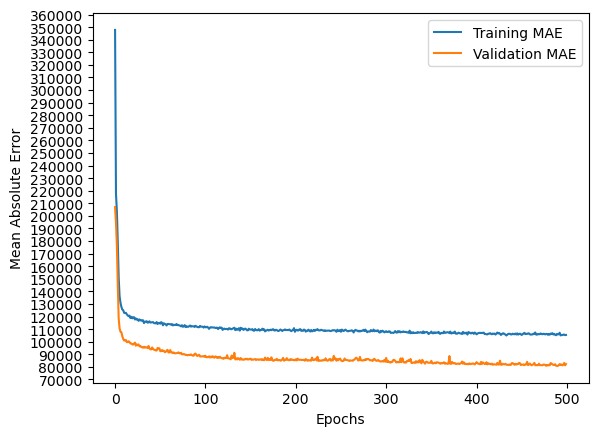

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model1 = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model1.summary()
model1.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model1.fit(X_train, y_train, epochs=500,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


In [22]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predict on validation or test set
y_pred_log = model1.predict(X_train).flatten()  # predictions in log scale
y_true_log = y_train  # true values in log scale

# Convert back to original scale
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_true_log)

# Calculate MAE in original price units
#mae_real = mean_absolute_error(y_true, y_pred)
#print("MAE in original price units:", mae_real)

620/620 ━━━━━━━━━━━━━━━━━━━━ 1s 976us/step


C:\Users\narut\AppData\Local\Temp\ipykernel_18240\2960422001.py:9: RuntimeWarning: overflow encountered in exp
  y_pred = np.exp(y_pred_log)
c:\Users\narut\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,753 (917.00 KB)

 Trainable params: 234,753 (917.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 142265188352.0000 - mae: 293913.9062 - val_loss: 26597271552.0000 - val_mae: 128466.7969


Epoch 2/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 22165848064.0000 - mae: 115690.4844 - val_loss: 21709885440.0000 - val_mae: 112888.7578
Epoch 3/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 18652127232.0000 - mae: 104908.5391 - val_loss: 16945724416.0000 - val_mae: 100318.5703
Epoch 4/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 18189649920.0000 - mae: 103327.6484 - val_loss: 17358043136.0000 - val_mae: 101931.3984
Epoch 5/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 17509312512.0000 - mae: 101505.3984 - val_loss: 19025328128.0000 - val_mae: 104859.6797
Epoch 6/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 17724190720.0000 - mae: 102075.4688 - val_loss: 19373490176.0000 - val_mae: 105365.1328
Epoch 7/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 17111244800.0000 - mae: 100131.1016 - val_loss: 16006197248.0000 - val_mae: 97682.4609
Epoch 8/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 17139905536.0000 - mae: 99713.6484 - val_loss:

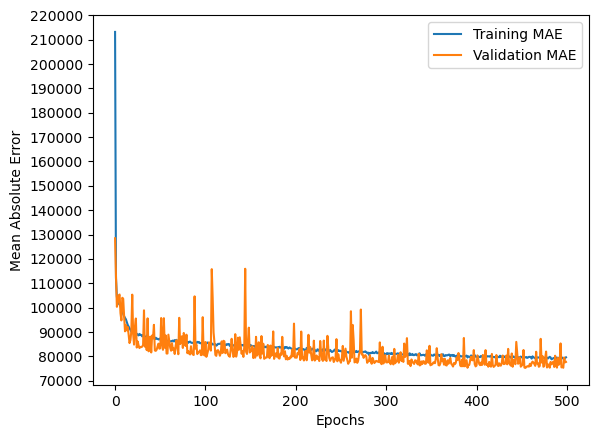

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model4 = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model4.summary()
model4.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model4.fit(X_train, y_train, epochs=500,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,153 (692.00 KB)

 Trainable params: 177,153 (692.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 173545177088.0000 - mae: 332330.2812 - val_loss: 48030150656.0000 - val_mae: 170716.9062
Epoch 2/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 38008647680.0000 - mae: 151722.8594 - val_loss: 19166246912.0000 - val_mae: 107948.4453
Epoch 3/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 21166000128.0000 - mae: 112614.1172 - val_loss: 17431572480.0000 - val_mae: 101953.6406
Epoch 4/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 20474798080.0000 - mae: 110239.0312 - val_loss: 17155960832.0000 - val_mae: 100473.8359
Epoch 5/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 19341502464.0000 - mae: 106466.1172 - val_loss: 17780373504.0000 - val_mae: 101748.1953
Epoch 6/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 18607734784.0000 - mae: 104283.4609 - val_loss: 16130067456.0000 - val_mae: 97755.4375
Epoch 7/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 18123935744.0000 - mae: 102410.9688 - val_los

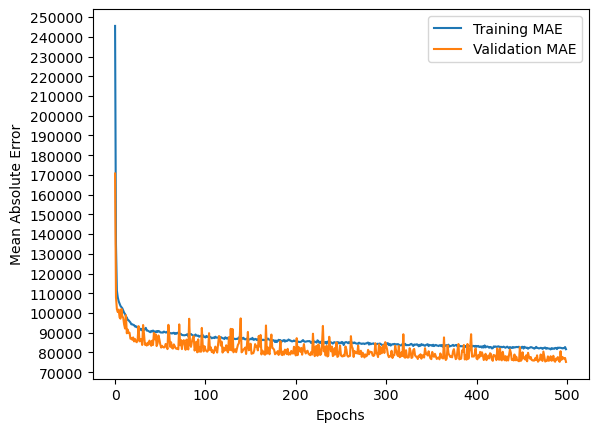

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model5 = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model5.summary()
model5.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model5.fit(X_train, y_train, epochs=500,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


In [25]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predict on validation or test set
y_pred_log = model5.predict(X_train).flatten()  # predictions in log scale
y_true_log = y_train  # true values in log scale

# Convert back to original scale
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_true_log)

# Calculate MAE in original price units
#mae_real = mean_absolute_error(y_true, y_pred)
#print("MAE in original price units:", mae_real)

620/620 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


C:\Users\narut\AppData\Local\Temp\ipykernel_18240\732905366.py:9: RuntimeWarning: overflow encountered in exp
  y_pred = np.exp(y_pred_log)
c:\Users\narut\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,617 (1.65 MB)

 Trainable params: 431,617 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 137772335104.0000 - mae: 285678.7812 - val_loss: 22686167040.0000 - val_mae: 117813.0234
Epoch 2/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 20896180224.0000 - mae: 112291.4453 - val_loss: 17723240448.0000 - val_mae: 102650.6641
Epoch 3/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 18653208576.0000 - mae: 105074.1406 - val_loss: 18771902464.0000 - val_mae: 106038.6562
Epoch 4/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 17613348864.0000 - mae: 101753.3828 - val_loss: 16103375872.0000 - val_mae: 97385.7266
Epoch 5/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 17968889856.0000 - mae: 102595.9609 - val_loss: 18850611200.0000 - val_mae: 103925.2188
Epoch 6/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 17588908032.0000 - mae: 101008.7812 - val_loss: 16852960256.0000 - val_mae: 100234.4219
Epoch 7/500
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 17076493312.0000 - mae: 99942.5547 - val_loss

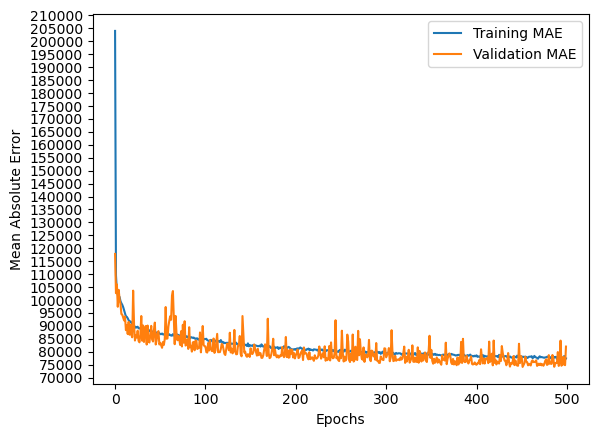

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model9 = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(512, activation="relu"),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(1)
])
model9.summary()
model9.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model9.fit(X_train, y_train, epochs=500,validation_data=(X_val, y_val))

import matplotlib.pyplot as plt

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()

# Add more y-axis ticks for detail
plt.locator_params(axis='y', nbins=30)  # Increase nbins for more ticks

plt.show()


In [27]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predict on validation or test set
y_pred_log = model9.predict(X_train).flatten()  # predictions in log scale
y_true_log = y_train  # true values in log scale

# Convert back to original scale
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_true_log)

# Calculate MAE in original price units
#mae_real = mean_absolute_error(y_true, y_pred)
#print("MAE in original price units:", mae_real)

620/620 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


C:\Users\narut\AppData\Local\Temp\ipykernel_18240\2234613665.py:9: RuntimeWarning: overflow encountered in exp
  y_pred = np.exp(y_pred_log)
c:\Users\narut\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Testing model with 3 hidden layers and 16 neurons
Layers: 3, Neurons: 16, Train MSE: 59423424512.00, Val MSE: 59199397888.00
Testing model with 3 hidden layers and 32 neurons


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layers: 3, Neurons: 32, Train MSE: 38906691584.00, Val MSE: 36162711552.00
Testing model with 3 hidden layers and 64 neurons


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Layers: 4, Neurons: 16, Train MSE: 26639892480.00, Val MSE: 24033728512.00
Testing model with 4 hidden layers and 32 neurons


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layers: 4, Neurons: 32, Train MSE: 17160335360.00, Val MSE: 17157351424.00
Testing model with 4 hidden layers and 64 neurons


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Layers: 4, Neurons: 64, Train MSE: 16375293952.00, Val MSE: 16561131520.00


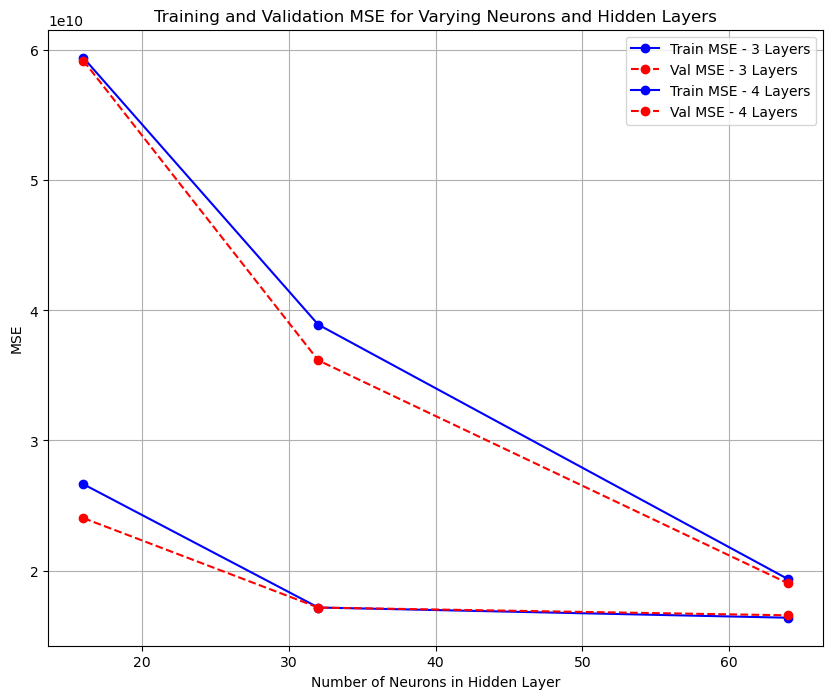

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Define neuron configurations (4 different numbers of neurons)
neuron_no = [ 16, 32, 64 ]  # Neurons
layer_no = [  3, 4  ]  # Number of hidden layers

mse_train = {layers: [] for layers in layer_no}  # Store training MSE for each layer configuration
mse_val = {layers: [] for layers in layer_no}  # Store validation MSE for each layer configuration

# Loop over different numbers of hidden layers (1, 2, 3, 4 layers)
for layers in layer_no:
    for neurons in neuron_no:
        print(f"Testing model with {layers} hidden layers and {neurons} neurons")
        
        # Build the model with the specified number of hidden layers and neurons
        model = Sequential()
        model.add(Dense(neurons, activation='relu', input_shape=(X_train.shape[1],)))  # Input + 1st hidden layer
        for _ in range(layers - 1):  # Add additional hidden layers
            model.add(Dense(neurons, activation='relu'))
        model.add(Dense(1))  # Output layer for regression
        
        # Compile and train the model
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32, verbose=0)

        # Store the MSE for both training and validation
        mse_train[layers].append(history.history['loss'][-1])  # Last epoch training MSE
        mse_val[layers].append(history.history['val_loss'][-1])  # Last epoch validation MSE
        print(f"Layers: {layers}, Neurons: {neurons}, Train MSE: {mse_train[layers][-1]:.2f}, Val MSE: {mse_val[layers][-1]:.2f}")

# Plot MSE for both training and validation for each configuration
plt.figure(figsize=(10, 8))

# Plot for each layer configuration
for layers in layer_no:
    plt.plot(neuron_no, mse_train[layers], marker='o', label=f'Train MSE - {layers} Layers', linestyle='-', color='blue')
    plt.plot(neuron_no, mse_val[layers], marker='o', label=f'Val MSE - {layers} Layers', linestyle='--', color='red')

plt.title("Training and Validation MSE for Varying Neurons and Hidden Layers")
plt.xlabel("Number of Neurons in Hidden Layer")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()
